# Chapter 6: Extending Hypothesis Testing


In this notebook, we extend hypothesis testing beyond means.

We will study:
- hypothesis tests for proportions
- tests for variability
- chi-square tests
- ANOVA
- one-sided confidence intervals


## Testing Proportions

In [1]:
# Suppose 44 out of 200 users clicked an advertisement

clicks <- 44
sample_size <- 200

sample_proportion <- clicks / sample_size

cat("Sample proportion:", sample_proportion, "\n")

Sample proportion: 0.22 


In [2]:
# Hypothesized click rate

p_0 <- 0.20

# Standard error for proportions

standard_error <- sqrt((p_0 * (1 - p_0)) / sample_size)

cat("Standard error:", round(standard_error, 4), "\n")

Standard error: 0.0283 


In [3]:
# Compute the z-score

z_score <- (sample_proportion - p_0) / standard_error

cat("z-score:", round(z_score, 2), "\n")

z-score: 0.71 


In [4]:
# Right-tailed p-value

p_value <- 1 - pnorm(z_score)

cat("p-value:", round(p_value, 4), "\n")

p-value: 0.2398 


In [5]:
cat("H0: p = 0.20\n")
cat("Ha: p > 0.20\n")

H0: p = 0.20
Ha: p > 0.20


In [6]:
alpha <- 0.05

if (p_value < alpha) {
  cat("Reject H0\n")
} else {
  cat("Fail to reject H0\n")
}

Fail to reject H0


## Visualizing the z-Distribution

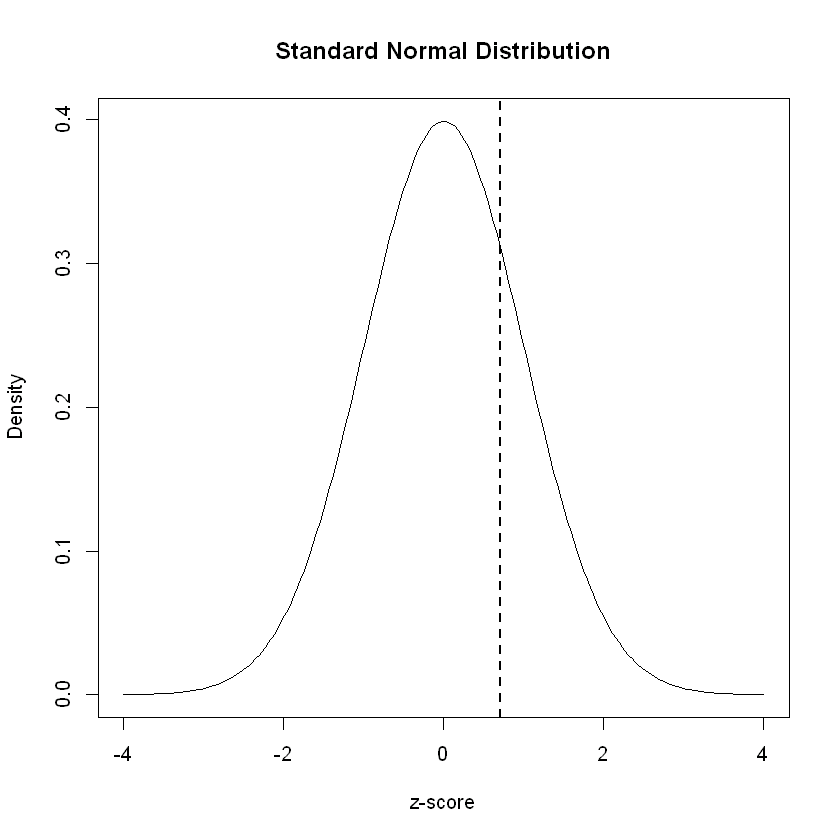

In [7]:
x <- seq(-4,4,length.out=200)
y <- dnorm(x)

plot(x,y,type="l",
     main="Standard Normal Distribution",
     xlab="z-score",
     ylab="Density")

abline(v=z_score,lty=2,lwd=2)

## Two-Tailed Proportion Test

In [8]:
successes <- 212
sample_size <- 400

sample_proportion <- successes/sample_size
p_0 <- 0.50

standard_error <- sqrt((p_0*(1-p_0))/sample_size)

z_score <- (sample_proportion-p_0)/standard_error

p_value <- 2*(1-pnorm(abs(z_score)))

cat("Sample proportion:", sample_proportion, "\n")
cat("z-score:", round(z_score,2), "\n")
cat("p-value:", round(p_value,4), "\n")

Sample proportion: 0.53 
z-score: 1.2 
p-value: 0.2301 


## Testing Variability

In [9]:
sample_std <- 7.2
claimed_std <- 5
sample_size <- 20

In [10]:
chi_square <- ((sample_size-1)*(sample_std^2))/(claimed_std^2)

cat("Chi-square statistic:", round(chi_square,2), "\n")

Chi-square statistic: 39.4 


In [11]:
df <- sample_size - 1
cat("Degrees of freedom:", df, "\n")

Degrees of freedom: 19 


In [12]:
p_value <- 1 - pchisq(chi_square, df)

cat("p-value:", round(p_value,4), "\n")

p-value: 0.0039 


In [13]:
cat("H0: sigma = 5\n")
cat("Ha: sigma > 5\n")

H0: sigma = 5
Ha: sigma > 5


In [14]:
alpha <- 0.05

if (p_value < alpha) {
  cat("Reject H0\n")
} else {
  cat("Fail to reject H0\n")
}

Reject H0


## Visualizing the Chi-Square Distribution

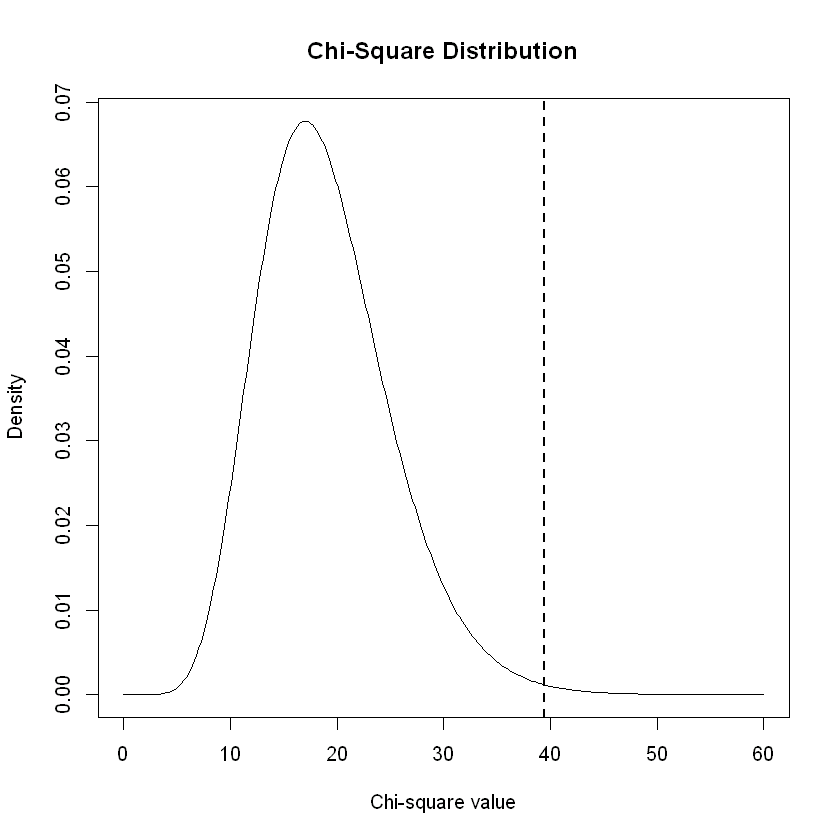

In [15]:
x <- seq(0,60,length.out=300)
y <- dchisq(x, df=df)

plot(x,y,type="l",
     main="Chi-Square Distribution",
     xlab="Chi-square value",
     ylab="Density")

abline(v=chi_square,lty=2,lwd=2)

# Appendix: ANOVA

## Comparing Multiple Groups

In [16]:
method_A <- c(78,80,82)
method_B <- c(79,81,83)
method_C <- c(88,90,92)

In [17]:
cat("Method A mean:", mean(method_A), "\n")
cat("Method B mean:", mean(method_B), "\n")
cat("Method C mean:", mean(method_C), "\n")

Method A mean: 80 
Method B mean: 81 
Method C mean: 90 


In [18]:
anova_result <- aov(
  c(method_A,method_B,method_C) ~
  factor(c(rep("A",3),rep("B",3),rep("C",3)))
)

summary(anova_result)

                                                 Df Sum Sq Mean Sq F value
factor(c(rep("A", 3), rep("B", 3), rep("C", 3)))  2    182      91   22.75
Residuals                                         6     24       4        
                                                  Pr(>F)   
factor(c(rep("A", 3), rep("B", 3), rep("C", 3))) 0.00158 **
Residuals                                                  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [19]:
cat("H0: mu_A = mu_B = mu_C\n")
cat("Ha: at least one mean differs\n")

H0: mu_A = mu_B = mu_C
Ha: at least one mean differs


In [20]:
cat("Check ANOVA p-value above and compare with alpha = 0.05\n")

Check ANOVA p-value above and compare with alpha = 0.05


## Visualizing Group Scores

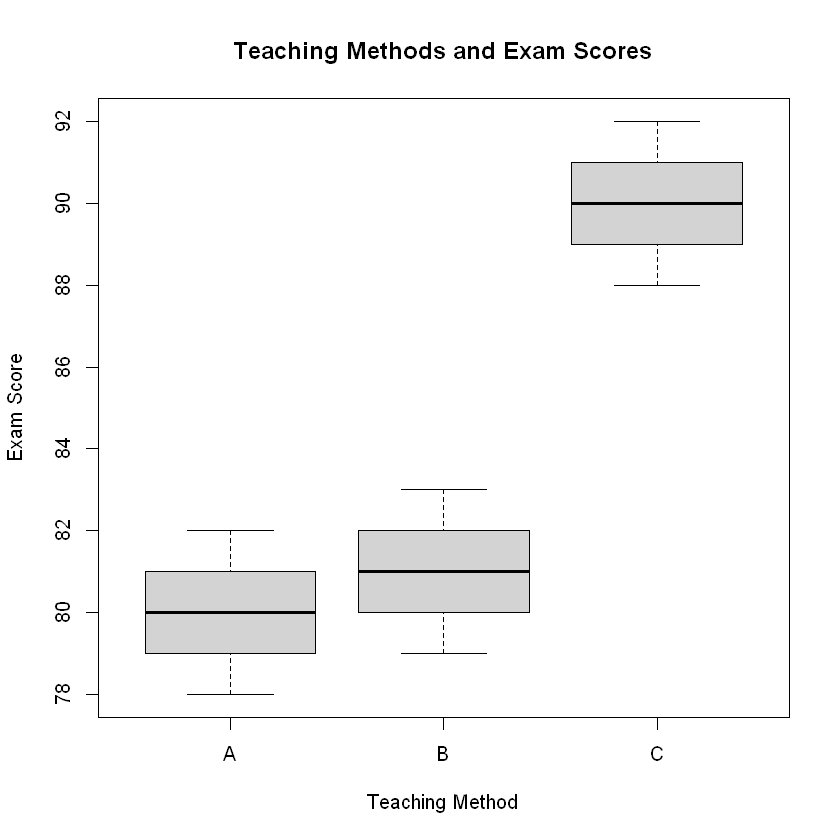

In [21]:
groups <- c("A","A","A","B","B","B","C","C","C")
scores <- c(method_A, method_B, method_C)

plot(as.factor(groups), scores,
     main="Teaching Methods and Exam Scores",
     xlab="Teaching Method",
     ylab="Exam Score")